### Agenda

1. **Conectarse con Google Drive**
2. **Importar librerías necesarias**
3. **Dataset -- matches.csv**
    * **3.1** Cargar Dataset
    * **3.2** Diccionario de Datos
    * **3.3** Exploración del Dataset
4. **Dataset -- matches_detail.csv**
    * **4.1** Cargar Dataset
    * **4.2** Diccionario de Datos
    * **4.3** Exploración del Dataset
5. **Preparación de los datos**
6. **Resumen general**
7. **Rendimiento**
    * **7.1** Winrate
        * **7.1.1** Winrate por hora jugada
        * **7.1.2** Winrate por día de la semana
        * **7.1.3** Winrate por tiempo jugado
        * **7.1.4** Gráfico radial
    * **7.2** KDA
    * **7.3** CS por minuto
    * **7.4** Oro por minuto
    * **7.5** Daño
    * **7.6** Vision
    * **7.7** Kills
    * **7.8** Asistencias
    * **7.9** Gráfico radial
8. **Consistencia**
9. **Pool de Campeones**
    * **9.1** Campeones jugados
    * **9.2** Winrate por campeón
10. **Builds**
    * **10.1** Objetos más utilizados
    * **10.2** Builds completas
11. **Posiciones**
    * **11.1** Distribución de posiciones
    * **11.2** Rendimiento según posición
    * **11.3** Campeón principal por posición

###1. Conectarse con google drive




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###2. Importar librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os
%matplotlib inline

###3. Dataset -- matches.csv

###3.1 Cargar Dataset

In [ ]:
#ruta_dataset = "/content/drive/MyDrive/Colab Notebooks/Fundamentos de Ciencia de Datos/Lol/matches.csv" # Elkin
ruta_dataset = "/content/drive/MyDrive/Ciencia De Datos/lol/matches.csv" # Humpty

print(f"Dataset cargado desde: {ruta_dataset}")
matches = pd.read_csv(ruta_dataset)
print(f"Partidas totales cargadas: {len(matches)}")

Dataset cargado desde: /content/drive/MyDrive/Ciencia De Datos/lol/matches.csv
Partidas totales cargadas: 77


###3.2 Diccionario de Datos
| Columna             | Descripcion
|:--------------------|:---------------------------------------------
| **match_id**        | Identificador unico de la partida
| **fecha**           | Fecha y hora en que se jugo la partida
| **cola**            | Tipo de cola (Ranked Solo/Duo, Normal, etc.)
| **game_mode**       | Modo de juego (Clasica, ARAM, etc.)
| **champion**        | Campeon utilizado por el jugador
| **position**        | Posicion/rol jugado (TOP, UTILITY, MIDDLE, etc.)
| **win**             | Resultado (True = Victoria, False = Derrota)
| **kills**           | Numero de asesinatos del jugador
| **deaths**          | Numero de veces que el jugador murio
| **assists**         | Numero de asistencias del jugador
| **kda**             | Relacion (kills + assists) / deaths
| **duracion_minutos**| Duracion total de la partida en minutos
| **cs_por_min**      | Subditos (minions) asesinados por minuto
| **gold_earned**     | Oro total ganado en la partida
| **gold_por_min**    | Oro generado por minuto
| **damage_dealt**    | Dano total infligido a campeones enemigos
| **damage_taken**    | Dano total recibido
| **vision_score**    | Puntuacion de contribucion a la vision del mapa
| **wards_placed**    | Centinelas (wards) colocados
| **wards_killed**    | Centinelas enemigos destruidos\

###3.3 Exploración del Dataset

In [ ]:
matches.head()

,match_id,fecha,duracion_minutos,game_mode,game_type,map_id,queue_id,cola,remake,puuid,...,vision_score,wards_placed,wards_killed,item_0,item_1,item_2,item_3,item_4,item_5,item_6
0,LA1_1749525517,2026-09-18 01:02:55.129,37.67,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,AYgVCm0ylg65XFwFVgE1VSvOjJNTXXYVZzCiL4GTuWbwuT...,...,60,25,5,3876,3143,3110,3009,1057,1028,3364
1,LA1_1749123417,2026-09-16 13:28:23.480,33.40,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,AYgVCm0ylg65XFwFVgE1VSvOjJNTXXYVZzCiL4GTuWbwuT...,...,59,25,5,3876,3143,3047,2504,1057,0,3364
2,LA1_1749099056,2026-09-16 09:50:38.644,30.30,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,AYgVCm0ylg65XFwFVgE1VSvOjJNTXXYVZzCiL4GTuWbwuT...,...,55,21,5,3876,3143,2031,3009,2504,1057,3364
3,LA1_1749092733,2026-09-16 09:10:23.337,28.35,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,AYgVCm0ylg65XFwFVgE1VSvOjJNTXXYVZzCiL4GTuWbwuT...,...,51,21,6,3876,3143,3111,2504,0,0,3364
4,LA1_1747451362,2026-09-09 09:38:17.319,37.98,CLASSIC,MATCHED_GAME,11,420,Ranked Solo/Duo,False,AYgVCm0ylg65XFwFVgE1VSvOjJNTXXYVZzCiL4GTuWbwuT...,...,67,22,7,3876,3110,3009,3050,3075,3190,3364


In [ ]:
print(f"Filas: {matches.shape[0]}, Columnas: {matches.shape[1]}")

Filas: 77, Columnas: 39


In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          77 non-null     object 
 1   fecha             77 non-null     object 
 2   duracion_minutos  77 non-null     float64
 3   game_mode         77 non-null     object 
 4   game_type         77 non-null     object 
 5   map_id            77 non-null     int64  
 6   queue_id          77 non-null     int64  
 7   cola              77 non-null     object 
 8   remake            77 non-null     bool   
 9   puuid             77 non-null     object 
 10  riot_id           77 non-null     object 
 11  champion          77 non-null     object 
 12  champion_id       77 non-null     int64  
 13  position          77 non-null     object 
 14  lane              77 non-null     object 
 15  win               77 non-null     bool   
 16  kills             77 non-null     int64  
 17 

###4. Dataset -- matches_detail.csv

###4.1 Cargar Dataset

In [ ]:
#ruta_dataset = "/content/drive/MyDrive/Colab Notebooks/Fundamentos de Ciencia de Datos/Lol/matches_detail.csv" #Elkin
ruta_dataset = "/content/drive/MyDrive/Ciencia De Datos/lol/matches_2026.csv" # Humpty

print(f"Dataset cargado desde: {ruta_dataset}")
matches_detail = pd.read_csv(ruta_dataset)
print(f"Partidas totales cargadas: {len(matches)}")

Dataset cargado desde: /content/drive/MyDrive/Ciencia De Datos/lol/matches_2026.csv
Partidas totales cargadas: 77


###4.2 Diccionario de Datos
| Columna             | Descripcion
|:--------------------|:---------------------------------------------|
| **match_id**        | Identificador único de la partida
| **fecha**           | Fecha y hora en que se jugó la partida
| **duracion_minutos**| Duración total de la partida en minutos
| **game_version**    | Versión del juego en la que se jugó la partida
| **queue_id**        | ID de la cola de emparejamiento
| **cola**            | Tipo de cola (Ranked Solo/Duo, Normal, etc.)
| **remake**          | Indica si la partida fue un "remake" (True/False)
| **equipo**          | Equipo al que pertenecía el jugador (azul/rojo)
| **champion**        | Campeón utilizado por el jugador
| **position**        | Posición/rol jugado (TOP, UTILITY, MIDDLE, etc.)
| **win**             | Resultado (True = Victoria, False = Derrota)
| **kills**           | Número de asesinatos del jugador
| **deaths**          | Número de veces que el jugador murió
| **assists**         | Número de asistencias del jugador
| **kda**             | Relación (kills + assists) / deaths
| **cs_por_min**      | Súbditos (minions) asesinados por minuto
| **gold_earned**     | Oro total ganado en la partida
| **gold_por_min**    | Oro generado por minuto
| **champ_level**     | Nivel del campeón al finalizar la partida
| **damage_dealt**    | Daño total infligido a campeones enemigos
| **damage_taken**    | Daño total recibido
| **curacion_total**  | Curación total realizada
| **curacion_a_aliados**| Curación realizada a aliados
| **escudos_a_aliados**| Escudos proporcionados a aliados
| **pociones_consumidas**| Número de pociones consumidas
| **hechizo_1**       | Primer hechizo de invocador utilizado
| **hechizo_1_usos**  | Número de usos del primer hechizo de invocador
| **hechizo_2**       | Segundo hechizo de invocador utilizado
| **hechizo_2_usos**  | Número de usos del segundo hechizo de invocador
| **uso_curar**       | Usos del hechizo 'Curar' (si aplica)
| **vision_score**    | Puntuación de contribución a la visión del mapa
| **wards_placed**    | Centinelas (wards) colocados
| **wards_killed**    | Centinelas enemigos destruidos
| **item_0**          | Primer objeto final comprado
| **item_1**          | Segundo objeto final comprado
| **item_2**          | Tercer objeto final comprado
| **item_3**          | Cuarto objeto final comprado
| **item_4**          | Quinto objeto final comprado
| **item_5**          | Sexto objeto final comprado
| **item_6**          | Objeto de baratija (trinket) comprado

###4.3 Exploración del Dataset

In [ ]:
matches_detail.head()

,match_id,fecha,duracion_minutos,game_version,queue_id,cola,remake,equipo,champion,position,...,vision_score,wards_placed,wards_killed,item_0,item_1,item_2,item_3,item_4,item_5,item_6
0,LA1_1749525517,2026-09-18 01:02:55.129,37.67,16.18.817.5716,420,Ranked Solo/Duo,False,azul,Thresh,UTILITY,...,60,25,5,Trineo del Solsticio,Presagio de Randuin,Corazón de Hielo,Botas de Rapidez,Capa de Negatrones,Cristal de Rubí,Lente del Oráculo
1,LA1_1749123417,2026-09-16 13:28:23.480,33.40,16.18.817.5716,420,Ranked Solo/Duo,False,rojo,Nautilus,UTILITY,...,59,25,5,Trineo del Solsticio,Presagio de Randuin,Punteras de Acero Revestidas,Rukerno Kaénico,Capa de Negatrones,0,Lente del Oráculo
2,LA1_1749099056,2026-09-16 09:50:38.644,30.30,16.18.817.5716,420,Ranked Solo/Duo,False,rojo,Nautilus,UTILITY,...,55,21,5,Trineo del Solsticio,Presagio de Randuin,Poción Reutilizable,Botas de Rapidez,Rukerno Kaénico,Capa de Negatrones,Lente del Oráculo
3,LA1_1749092733,2026-09-16 09:10:23.337,28.35,16.18.817.5716,420,Ranked Solo/Duo,False,rojo,Thresh,UTILITY,...,51,21,6,Trineo del Solsticio,Presagio de Randuin,Botas de Mercurio,Rukerno Kaénico,0,0,Lente del Oráculo
4,LA1_1747451362,2026-09-09 09:38:17.319,37.98,16.17.810.4348,420,Ranked Solo/Duo,False,rojo,Thresh,UTILITY,...,67,22,7,Trineo del Solsticio,Corazón de Hielo,Botas de Rapidez,Convergencia de Zeke,Cota de Espinas,Relicario de los Solari de Hierro,Lente del Oráculo


In [ ]:
print(f"Filas: {matches_detail.shape[0]}, Columnas: {matches_detail.shape[1]}")

Filas: 77, Columnas: 40


In [ ]:
matches_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             77 non-null     object 
 1   fecha                77 non-null     object 
 2   duracion_minutos     77 non-null     float64
 3   game_version         77 non-null     object 
 4   queue_id             77 non-null     int64  
 5   cola                 77 non-null     object 
 6   remake               77 non-null     bool   
 7   equipo               77 non-null     object 
 8   champion             77 non-null     object 
 9   position             77 non-null     object 
 10  win                  77 non-null     bool   
 11  kills                77 non-null     int64  
 12  deaths               77 non-null     int64  
 13  assists              77 non-null     int64  
 14  kda                  77 non-null     float64
 15  cs_por_min           77 non-null     float

###5. Preparación de los datos

In [ ]:
#Copiar para dejar los datasets originales intactos
df_matches = matches.copy()
df_matches_detail = matches_detail.copy()

In [ ]:
#Filtramos por partidas en las que NO hizo remake
df_matches = df_matches[df_matches["remake"] == False]
df_matches_detail = df_matches_detail[df_matches_detail["remake"] == False]

In [ ]:
# Convertir fecha
df_matches["fecha"] = pd.to_datetime(df_matches["fecha"], errors="coerce")
df_matches_detail["fecha"] = pd.to_datetime(df_matches_detail["fecha"], errors="coerce")

In [ ]:
# Orden cronológico
df_matches = df_matches.sort_values("fecha").reset_index(drop=True)
df_matches_detail = df_matches_detail.sort_values("fecha").reset_index(drop=True)

In [ ]:
df_matches["fecha"] = pd.to_datetime(df_matches["fecha"])

df_matches["hora"] = df_matches["fecha"].dt.hour

dias_es = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
df_matches["dia_semana"] = pd.Categorical.from_codes(
    df_matches["fecha"].dt.dayofweek,
    categories=dias_es,
    ordered=True
)

###6. Resumen general

In [ ]:
resumen_general = pd.DataFrame({
    "Métrica": [
        "Partidas",
        "Victorias",
        "Derrotas",
        "Winrate",
        "KDA promedio",
        "CS/min promedio",
        "Oro/min promedio",
        "Daño promedio",
        "Daño recibido promedio",
        "Vision Score promedio"
    ],
    "Valor": [
        len(df_matches),
        df_matches["win"].sum(),
        (~df_matches["win"]).sum(),
        df_matches["win"].mean() * 100,
        df_matches["kda"].mean(),
        df_matches["cs_por_min"].mean(),
        df_matches["gold_por_min"].mean(),
        df_matches["damage_dealt"].mean(),
        df_matches["damage_taken"].mean(),
        df_matches["vision_score"].mean()
    ]
})

display(resumen_general.round(2))

,Métrica,Valor
0,Partidas,69.00
1,Victorias,36.00
2,Derrotas,33.00
3,Winrate,52.17
4,KDA promedio,3.19
5,CS/min promedio,2.00
6,Oro/min promedio,318.20
7,Daño promedio,14854.59
8,Daño recibido promedio,26952.99
9,Vision Score promedio,53.06


###7. Rendimiento

###7.1 Winrate

In [ ]:
partidas = len(df_matches)
victorias = df_matches["win"].sum()
derrotas = (~df_matches["win"]).sum()
winrate = df_matches["win"].mean() * 100

winrate_tabla = pd.DataFrame({
    "Métrica": [
        "Partidas totales",
        "Victorias",
        "Derrotas",
        "Winrate"
    ],
    "Valor": [
        partidas,
        victorias,
        derrotas,
        f"{winrate:.2f}%"
    ]
})

display(winrate_tabla)

,Métrica,Valor
0,Partidas totales,69
1,Victorias,36
2,Derrotas,33
3,Winrate,52.17%


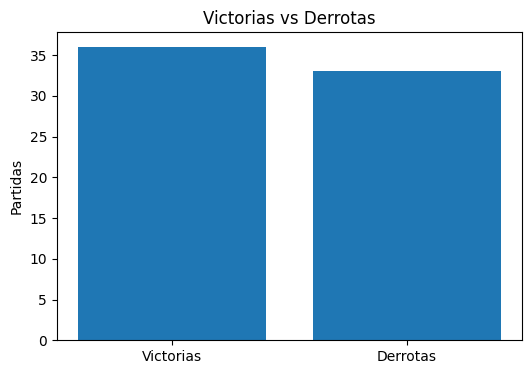

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Victorias", "Derrotas"],
    [victorias, derrotas]
)

plt.title("Victorias vs Derrotas")
plt.ylabel("Partidas")

plt.show()

In [ ]:
#Comparación:Victoria VS Derrota
metricas = [
    "kills", "deaths", "assists", "kda", "cs_por_min",
    "gold_por_min", "damage_dealt", "damage_taken",
    "vision_score", "wards_placed", "wards_killed"
]

comparacion = df_matches.groupby("win")[metricas].mean()
comparacion.insert(0, "partidas", df_matches["win"].value_counts())
comparacion.insert(1, "winrate", (comparacion["partidas"] / len(df_matches) * 100))

tabla_final = comparacion.T.round(2).rename(columns={True: "Victoria", False: "Derrota"})

tabla_final

win,Derrota,Victoria
partidas,33.00,36.00
winrate,47.83,52.17
kills,3.52,4.58
deaths,6.79,5.47
assists,7.27,12.42
kda,1.71,4.55
cs_por_min,2.07,1.94
gold_por_min,301.95,333.09
damage_dealt,13924.42,15707.25
damage_taken,25752.12,28053.78


###7.1.1 Winrate por hora jugada

In [ ]:
hora_stats = df_matches.groupby("hora").agg(
    winrate_pct=("win", "mean"),
    partidas=("win", "count")
)

hora_stats["winrate_%"] = (hora_stats["winrate_pct"] * 100).round(2)
hora_stats = hora_stats[["winrate_%", "partidas"]]

hora_stats

,winrate_%,partidas
hora,,
1,0.00,1
6,0.00,1
7,66.67,3
8,66.67,3
9,83.33,6
10,0.00,1
11,0.00,2
12,0.00,1
13,62.50,8


###7.1.2 Winrate por dia de la semana

In [ ]:
resumen_dia = df_matches.groupby("dia_semana", observed=False).agg(
    winrate_pct=("win", "mean"),
    partidas_total=("win", "count")
)

resumen_dia["winrate_%"] = (resumen_dia["winrate_pct"] * 100).round(2)
resumen_dia = resumen_dia[["winrate_%", "partidas_total"]]
resumen_dia.index = dias_es

resumen_dia

,winrate_%,partidas_total
Lunes,75.00,4
Martes,60.00,5
Miércoles,90.00,10
Jueves,25.00,4
Viernes,36.36,11
Sábado,47.37,19
Domingo,43.75,16


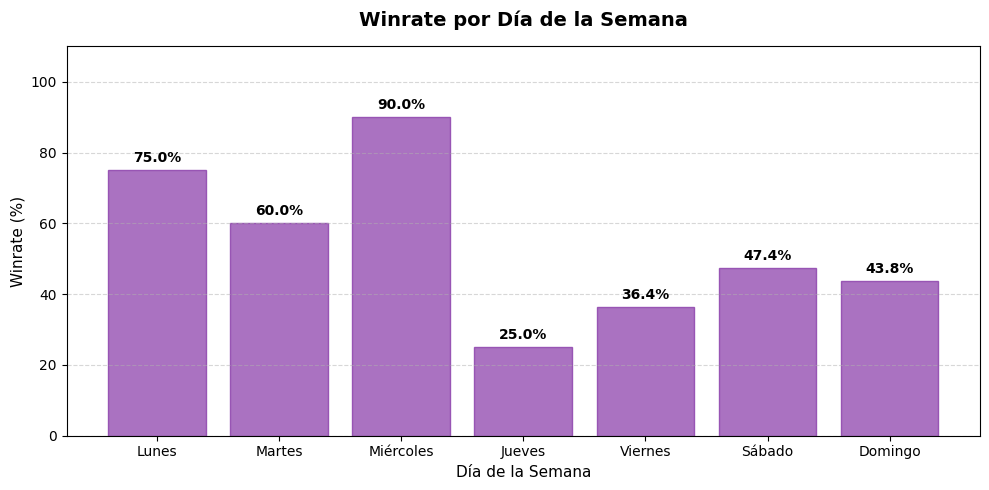

In [ ]:
# Usar los datos agrupados de resumen_dia
dias = resumen_dia.index
winrates = resumen_dia['winrate_%']

plt.figure(figsize=(10, 5))

# Crear gráfico de barras con un diseño limpio
bars = plt.bar(
    dias,
    winrates,
    color='#9b59b6',
    edgecolor='#8e44ad',
    alpha=0.85
)

# Agregar los porcentajes arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval + 1.5,
        f"{yval:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Personalizar el gráfico
plt.title("Winrate por Día de la Semana", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Día de la Semana", fontsize=11)
plt.ylabel("Winrate (%)", fontsize=11)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###7.1.3 Winrate por tiempo jugado

In [ ]:
df_matches["duracion_categoria"] = pd.cut(
    df_matches["duracion_minutos"],
    bins=[0, 20, 25, 30, 35, 100],
    labels=["<20 min", "20-25 min", "25-30 min", "30-35 min", ">35 min"]
)

duracion_stats = df_matches.groupby("duracion_categoria", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count"),
    kda=("kda", "mean"),
    deaths=("deaths", "mean")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

duracion_stats

,winrate_%,partidas,kda,deaths
duracion_categoria,,,,
<20 min,40.00,5,3.61,2.40
20-25 min,0.00,6,1.05,4.50
25-30 min,52.94,17,4.62,5.24
30-35 min,61.90,21,3.13,5.86
>35 min,60.00,20,2.58,8.50


###7.1.4 Gráfico radial

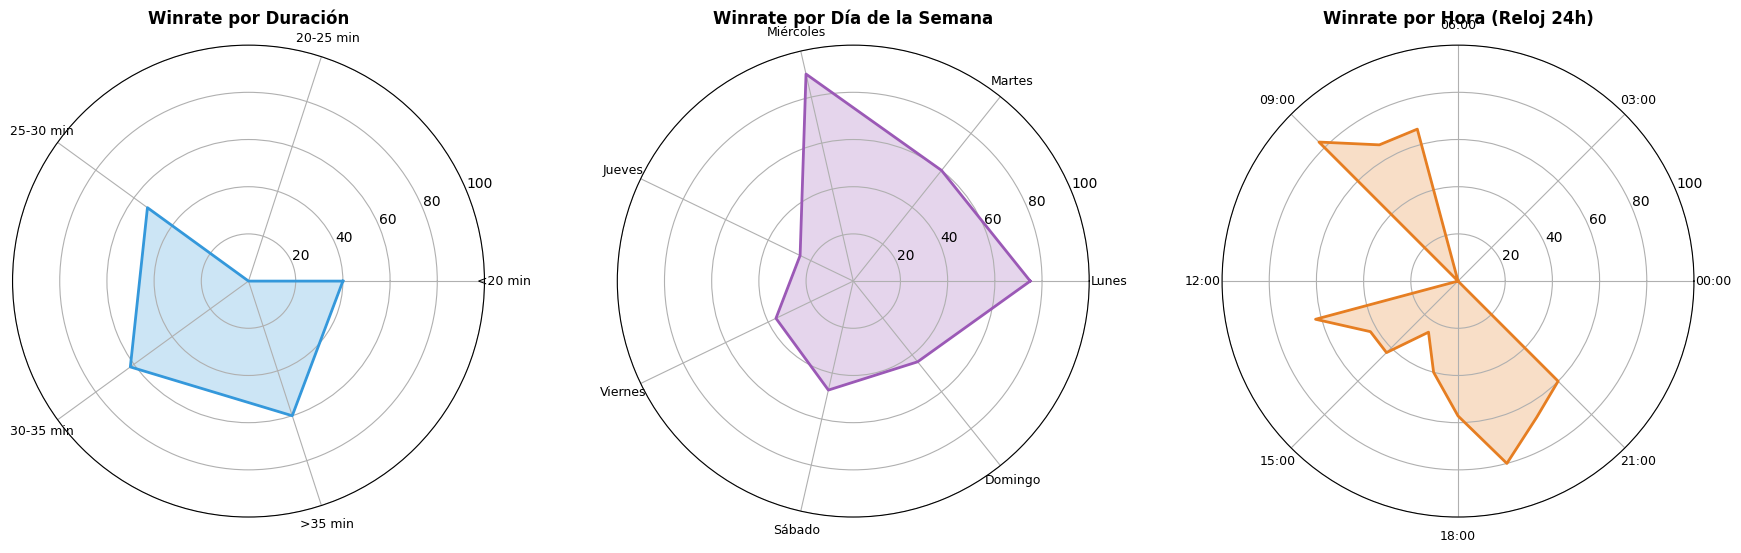

In [ ]:
# Promedio de cada estadística dividido entre su máximo histórico (escala de 0 a 1).

# --- DATOS 1: Duración de partida ---
cat_dur = duracion_stats.index.astype(str).tolist()
vals_dur = duracion_stats["winrate_%"].tolist() + [duracion_stats["winrate_%"].iloc[0]]
ang_dur = np.linspace(0, 2 * np.pi, len(cat_dur), endpoint=False).tolist() + [0]

# --- DATOS 2: Día de la semana ---
cat_dia = resumen_dia.index.astype(str).tolist()
vals_dia = resumen_dia["winrate_%"].tolist() + [resumen_dia["winrate_%"].iloc[0]]
ang_dia = np.linspace(0, 2 * np.pi, len(cat_dia), endpoint=False).tolist() + [0]

# --- DATOS 3: Hora del día (24 horas) ---
hora_full = hora_stats.reindex(range(24), fill_value=0)
cat_hora = [f"{h:02d}:00" for h in range(24)]
vals_hora = hora_full["winrate_%"].tolist() + [hora_full["winrate_%"].iloc[0]]
ang_hora = np.linspace(0, 2 * np.pi, 24, endpoint=False).tolist() + [0]



fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5), subplot_kw=dict(polar=True))


# --- Grafica 1: Duración de partida ---
ax1.plot(ang_dur, vals_dur, color="#3498db", linewidth=2)
ax1.fill(ang_dur, vals_dur, color="#3498db", alpha=0.25)
ax1.set_xticks(ang_dur[:-1])
ax1.set_xticklabels(cat_dur, fontsize=9)
ax1.set_ylim(0, 100)
ax1.set_title("Winrate por Duración", pad=15, fontweight="bold")

# --- Grafica 2: Día de la semana ---
ax2.plot(ang_dia, vals_dia, color="#9b59b6", linewidth=2)
ax2.fill(ang_dia, vals_dia, color="#9b59b6", alpha=0.25)
ax2.set_xticks(ang_dia[:-1])
ax2.set_xticklabels(cat_dia, fontsize=9)
ax2.set_ylim(0, 100)
ax2.set_title("Winrate por Día de la Semana", pad=15, fontweight="bold")

# --- Grafica 3: Hora del día (Reloj 24h) ---
ax3.plot(ang_hora, vals_hora, color="#e67e22", linewidth=2)
ax3.fill(ang_hora, vals_hora, color="#e67e22", alpha=0.25)
ax3.set_xticks(ang_hora[:-1][::3])
ax3.set_xticklabels(cat_hora[::3], fontsize=9)
ax3.set_ylim(0, 100)
ax3.set_title("Winrate por Hora (Reloj 24h)", pad=15, fontweight="bold")

plt.tight_layout()
plt.show()

###7.2 KDA

In [ ]:
kda_stats = pd.DataFrame({
    "Métrica": [
        "Kills promedio",
        "Deaths promedio",
        "Assists promedio",
        "KDA promedio"
    ],
    "Valor": [
        df_matches["kills"].mean(),
        df_matches["deaths"].mean(),
        df_matches["assists"].mean(),
        df_matches["kda"].mean()
    ]
})

display(kda_stats.round(2))

,Métrica,Valor
0,Kills promedio,4.07
1,Deaths promedio,6.10
2,Assists promedio,9.96
3,KDA promedio,3.19


In [ ]:
# Winrate de kda
df_matches["KDA"] = pd.cut(
    df_matches["kda"],
    bins=[0, 2, 3.5, 5, 100],
    labels=["< 2", "2-3.5", "3.5-5", "> 5"]
)

kda_stats = df_matches.groupby("KDA", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

kda_stats

,winrate_%,partidas
KDA,,
< 2,24.24,33
2-3.5,78.57,14
3.5-5,91.67,12
> 5,75.00,8


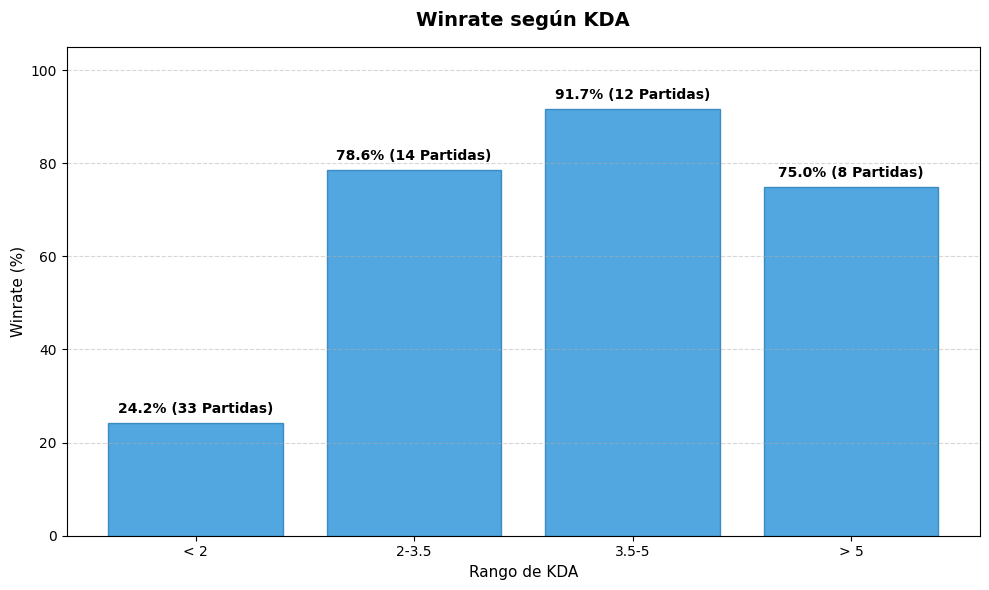

In [ ]:
kda_winrates = kda_stats['winrate_%']
kda_categories = kda_stats.index.astype(str)
kda_partidas = kda_stats['partidas']

plt.figure(figsize=(10, 6))
bars = plt.bar(
    kda_categories,
    kda_winrates,
    color='#3498db',
    edgecolor='#2980b9',
    alpha=0.85
)

for bar, num_partidas in zip(bars, kda_partidas):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1.5,
        f"{yval:.1f}% ({int(num_partidas)} Partidas)",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title("Winrate según KDA", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rango de KDA", fontsize=11)
plt.ylabel("Winrate (%)", fontsize=11)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###7.3 CS por minuto

In [ ]:
cs_stats = pd.DataFrame({
    "Métrica": [
        "CS/min promedio",
        "CS/min mediano",
        "CS/min mínimo",
        "CS/min máximo"
    ],
    "Valor": [
        df_matches["cs_por_min"].mean(),
        df_matches["cs_por_min"].median(),
        df_matches["cs_por_min"].min(),
        df_matches["cs_por_min"].max()
    ]
})

display(cs_stats.round(2))

,Métrica,Valor
0,CS/min promedio,2.00
1,CS/min mediano,1.55
2,CS/min mínimo,0.55
3,CS/min máximo,5.73


In [ ]:
## Winrate de cs_por_min
df_matches["cs por minuto"] = pd.cut(
    df_matches["cs_por_min"],
    bins=[0, 4, 6, 8, 100],
    labels=["< 4", "4-6", "6-8", "> 8"]
)

cs_stats = df_matches.groupby("cs por minuto", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

cs_stats

,winrate_%,partidas
cs por minuto,,
< 4,52.46,61
4-6,50.00,8
6-8,NaN,0
> 8,NaN,0


###7.4 Oro por minuto

In [ ]:
oro_stats = pd.DataFrame({
    "Métrica": [
        "Oro/min promedio",
        "Oro/min mediano",
        "Oro/min mínimo",
        "Oro/min máximo"
    ],
    "Valor": [
        df_matches["gold_por_min"].mean(),
        df_matches["gold_por_min"].median(),
        df_matches["gold_por_min"].min(),
        df_matches["gold_por_min"].max()
    ]
})

display(oro_stats.round(2))

,Métrica,Valor
0,Oro/min promedio,318.2
1,Oro/min mediano,309.4
2,Oro/min mínimo,188.6
3,Oro/min máximo,448.2


In [ ]:
# Winrate de gold_por_min
df_matches["oro por minuto"] = pd.cut(
    df_matches["gold_por_min"],
    bins=[0, 300, 400, 500, 1000],
    labels=["< 300", "300-400", "400-500", "> 500"]
)

gold_stats = df_matches.groupby("oro por minuto", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

gold_stats

,winrate_%,partidas
oro por minuto,,
< 300,37.04,27
300-400,62.16,37
400-500,60.00,5
> 500,NaN,0


###7.5 Daño

In [ ]:
daño_stats = pd.DataFrame({
    "Métrica": [
        "Daño promedio",
        "Daño mediano",
        "Daño mínimo",
        "Daño máximo"
    ],
    "Valor": [
        df_matches["damage_dealt"].mean(),
        df_matches["damage_dealt"].median(),
        df_matches["damage_dealt"].min(),
        df_matches["damage_dealt"].max()
    ]
})

display(daño_stats.round(2))

,Métrica,Valor
0,Daño promedio,14854.59
1,Daño mediano,12876.00
2,Daño mínimo,1797.00
3,Daño máximo,60054.00


In [ ]:
#Winrate damage_dealt
df_matches["daño"] = pd.cut(
    df_matches["damage_dealt"],
    bins=[0, 10000, 20000, 30000, 1000000],
    labels=["< 10k", "10k-20k", "20k-30k", "> 30k"]
)

damage_stats = df_matches.groupby("daño", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

damage_stats

,winrate_%,partidas
daño,,
< 10k,45.83,24
10k-20k,50.00,28
20k-30k,69.23,13
> 30k,50.00,4


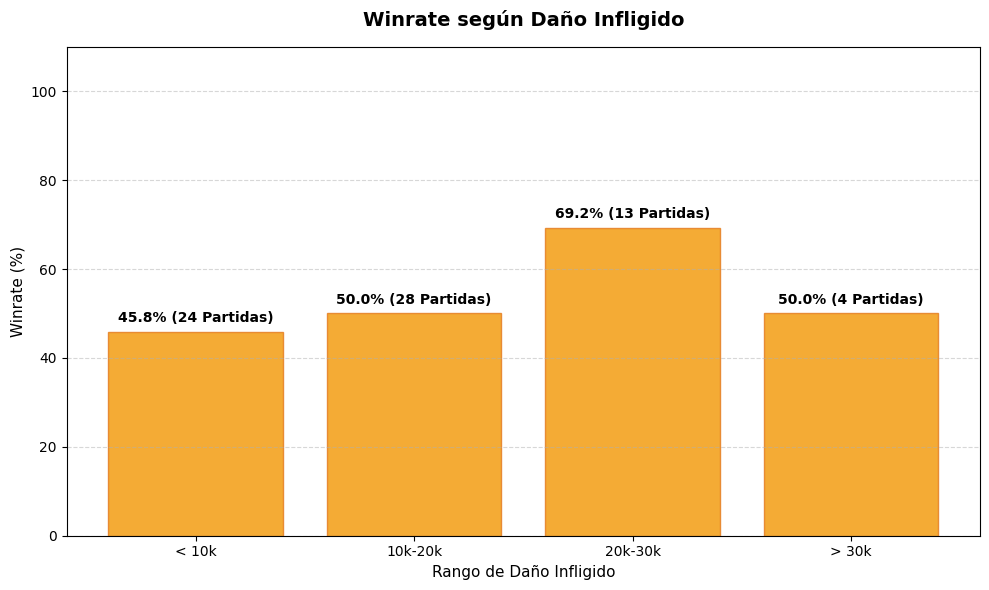

In [ ]:
damage_winrates = damage_stats['winrate_%']
damage_categories = damage_stats.index.astype(str)
damage_partidas = damage_stats['partidas']

plt.figure(figsize=(10, 6))
bars = plt.bar(
    damage_categories,
    damage_winrates,
    color='#f39c12',
    edgecolor='#e67e22',
    alpha=0.85
)

# Añadir etiquetas de valor y número de partidas sobre cada barra
for bar, num_partidas in zip(bars, damage_partidas):
    yval = bar.get_height()
    if not pd.isna(yval): # Check for NaN values before displaying
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + 1.5,
            f"{yval:.1f}% ({int(num_partidas)} Partidas)",
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.title("Winrate según Daño Infligido", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rango de Daño Infligido", fontsize=11)
plt.ylabel("Winrate (%)", fontsize=11)
plt.ylim(0, 110) # Adjust y-limit for winrate percentages
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###7.6 Vision

In [ ]:
vision_stats = pd.DataFrame({
    "Métrica": [
        "Vision Score promedio",
        "Vision Score mediano",
        "Vision Score mínimo",
        "Vision Score máximo",
        "Wards colocados promedio",
        "Wards colocados mediano",
        "Wards colocados mínimo",
        "Wards colocados máximo",
        "Wards destruidos promedio",
        "Wards destruidos mediano",
        "Wards destruidos mínimo",
        "Wards destruidos máximo"
    ],
    "Valor": [
        df_matches["vision_score"].mean(),
        df_matches["vision_score"].median(),
        df_matches["vision_score"].min(),
        df_matches["vision_score"].max(),
        df_matches["wards_placed"].mean(),
        df_matches["wards_placed"].median(),
        df_matches["wards_placed"].min(),
        df_matches["wards_placed"].max(),
        df_matches["wards_killed"].mean(),
        df_matches["wards_killed"].median(),
        df_matches["wards_killed"].min(),
        df_matches["wards_killed"].max()
    ]
})

display(vision_stats.round(2))

,Métrica,Valor
0,Vision Score promedio,53.06
1,Vision Score mediano,55.00
2,Vision Score mínimo,3.00
3,Vision Score máximo,111.00
4,Wards colocados promedio,17.39
5,Wards colocados mediano,19.00
6,Wards colocados mínimo,2.00
7,Wards colocados máximo,32.00
8,Wards destruidos promedio,5.42
9,Wards destruidos mediano,5.00


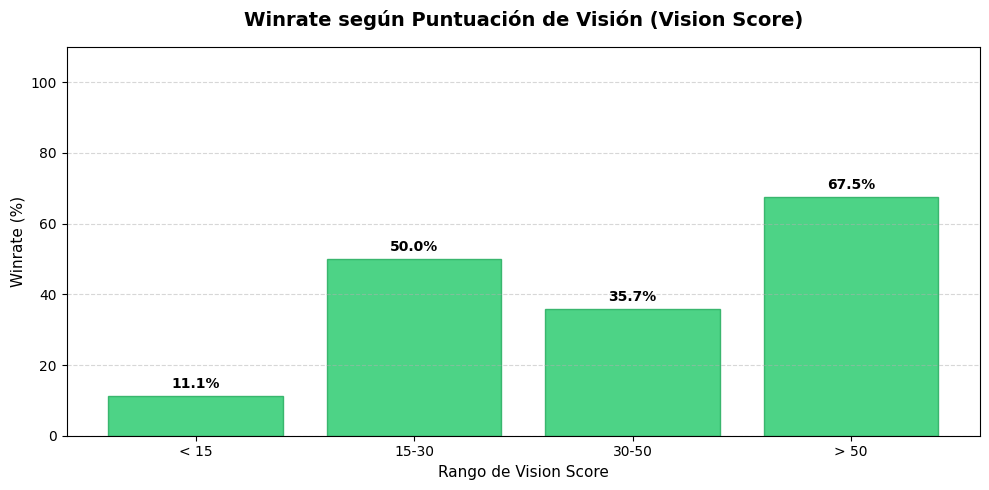

In [ ]:
# 1. Crear las categorías de visión en el DataFrame
df_matches["vision"] = pd.cut(
    df_matches["vision_score"],
    bins=[0, 15, 30, 50, 1000],
    labels=["< 15", "15-30", "30-50", "> 50"]
)

# 2. Agrupar para obtener el winrate (%) y cantidad de partidas por categoría
vision_winrate_df = df_matches.groupby("vision", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

# 3. Obtener categorías y winrates
categorias_vision = vision_winrate_df.index
winrate_vision = vision_winrate_df['winrate_%']

plt.figure(figsize=(10, 5))

# Crear gráfico de barras con un diseño limpio y moderno
bars = plt.bar(
    categorias_vision,
    winrate_vision,
    color='#2ecc71',
    edgecolor='#27ae60',
    alpha=0.85
)

# Agregar etiquetas de porcentaje arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):
        plt.text(
            bar.get_x() + bar.get_width()/2.0,
            yval + 1.5,
            f"{yval:.1f}%",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Personalización de títulos y ejes
plt.title("Winrate según Puntuación de Visión (Vision Score)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rango de Vision Score", fontsize=11)
plt.ylabel("Winrate (%)", fontsize=11)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###7.7 Kills

In [ ]:
kills_stats = pd.DataFrame({
    "Métrica": [
        "Kills promedio",
        "Kills mediano",
        "Kills mínimo",
        "Kills máximo"
    ],
    "Valor": [
        df_matches["kills"].mean(),
        df_matches["kills"].median(),
        df_matches["kills"].min(),
        df_matches["kills"].max()
    ]
})

display(kills_stats.round(2))

,Métrica,Valor
0,Kills promedio,4.07
1,Kills mediano,3.00
2,Kills mínimo,0.00
3,Kills máximo,17.00


In [ ]:
# Winrate kills
df_matches["asesinatos"] = pd.cut(
    df_matches["kills"],
    bins=[0, 3, 6, 10, 100],
    labels=["< 3", "3-6", "6-10", "> 10"]
)

kills_stats = df_matches.groupby("asesinatos", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

kills_stats

,winrate_%,partidas
asesinatos,,
< 3,44.83,29
3-6,57.89,19
6-10,81.82,11
> 10,33.33,3


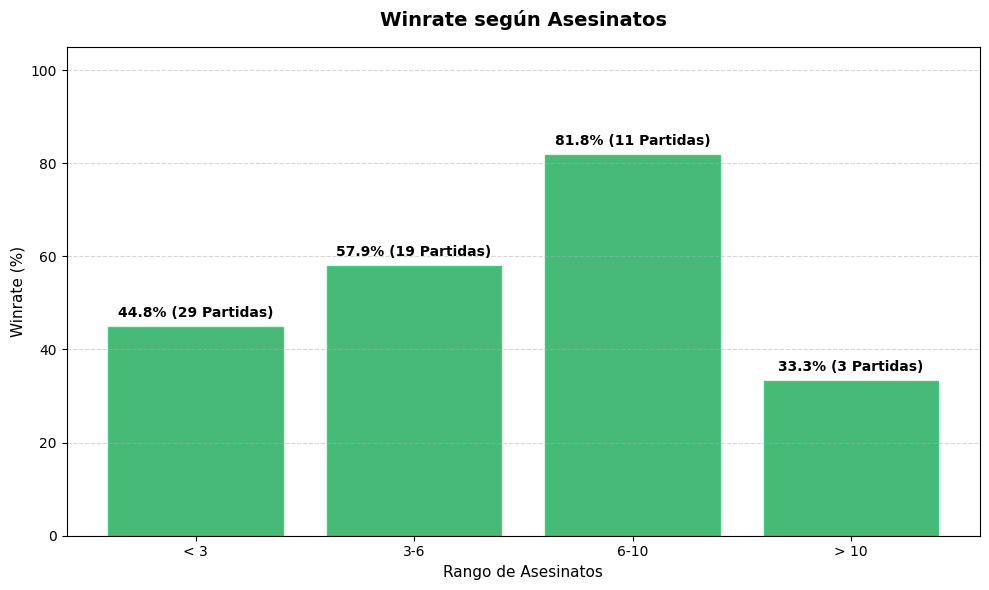

In [ ]:
kills_winrates = kills_stats['winrate_%']
kills_categories = kills_stats.index.astype(str)
kills_partidas = kills_stats['partidas']

plt.figure(figsize=(10, 6))
bars = plt.bar(
    kills_categories,
    kills_winrates,
    color='#27ae60', # Un color verde diferente
    edgecolor='#2ecc71',
    alpha=0.85
)

# Añadir etiquetas de valor y número de partidas sobre cada barra
for bar, num_partidas in zip(bars, kills_partidas):
    yval = bar.get_height()
    if not pd.isna(yval): # Verificar si el valor no es NaN antes de mostrar
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + 1.5,
            f"{yval:.1f}% ({int(num_partidas)} Partidas)",
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.title("Winrate según Asesinatos", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rango de Asesinatos", fontsize=11)
plt.ylabel("Winrate (%)", fontsize=11)
plt.ylim(0, 105) # Ajustar el límite y para acomodar las etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###7.8 Asistencias

In [ ]:
assists_stats = pd.DataFrame({
    "Métrica": [
        "Asistencias promedio",
        "Asistencias mediano",
        "Asistencias mínimo",
        "Asistencias máximo"
    ],
    "Valor": [
        df_matches["assists"].mean(),
        df_matches["assists"].median(),
        df_matches["assists"].min(),
        df_matches["assists"].max()
    ]
})

display(assists_stats.round(2))

,Métrica,Valor
0,Asistencias promedio,9.96
1,Asistencias mediano,9.00
2,Asistencias mínimo,0.00
3,Asistencias máximo,25.00


In [ ]:
# Winrate de assists
df_matches["asistencias"] = pd.cut(
    df_matches["assists"],
    bins=[0, 5, 10, 15, 100],
    labels=["< 5", "5-10", "10-15", "> 15"]
)

assists_stats = df_matches.groupby("asistencias", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

assists_stats

,winrate_%,partidas
asistencias,,
< 5,23.53,17
5-10,50.00,20
10-15,66.67,15
> 15,80.00,15


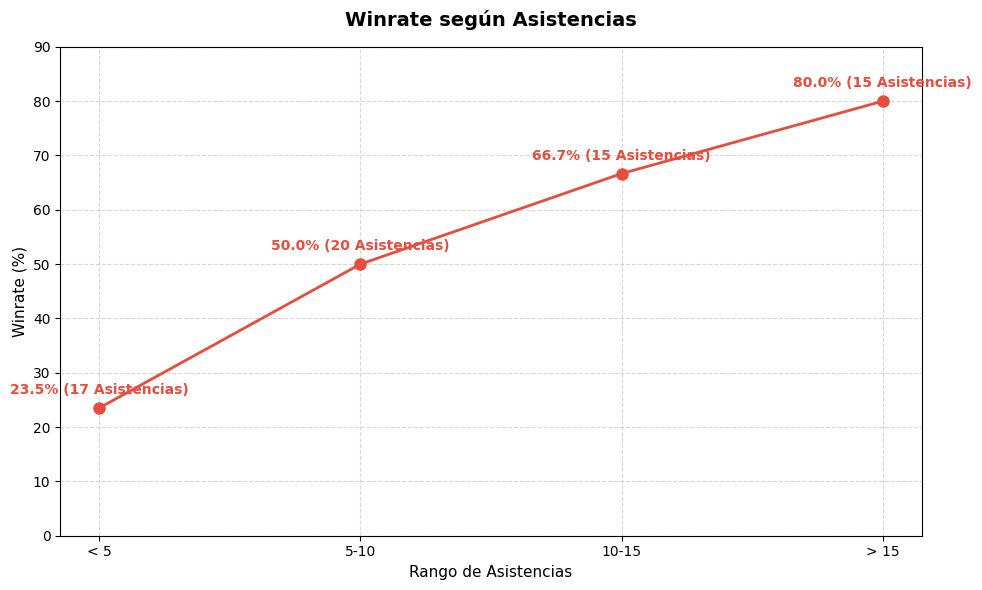

In [ ]:
df_matches["asistencias"] = pd.cut(
    df_matches["assists"],
    bins=[0, 5, 10, 15, 100],
    labels=["< 5", "5-10", "10-15", "> 15"]
)

assists_stats = df_matches.groupby("asistencias", observed=False).agg(
    winrate_pct=("win", lambda x: x.mean() * 100),
    partidas=("win", "count")
).round(2).rename(columns={"winrate_pct": "winrate_%"})

assists_winrates = assists_stats['winrate_%']
assists_categories = assists_stats.index.astype(str)
assists_partidas = assists_stats['partidas']

plt.figure(figsize=(10, 6))
plt.plot(
    assists_categories,
    assists_winrates,
    marker='o',
    linestyle='-',
    color='#e74c3c',
    linewidth=2,
    markersize=8
)

for i, (x, y) in enumerate(zip(assists_categories, assists_winrates)):
    plt.text(
        x,
        y + 2,
        f"{y:.1f}% ({int(assists_partidas.iloc[i])} Asistencias)",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#e74c3c'
    )

plt.title("Winrate según Asistencias", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rango de Asistencias", fontsize=11)
plt.ylabel("Winrate (%)", fontsize=11)
plt.ylim(0, 90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###7.9 Gráfico radial

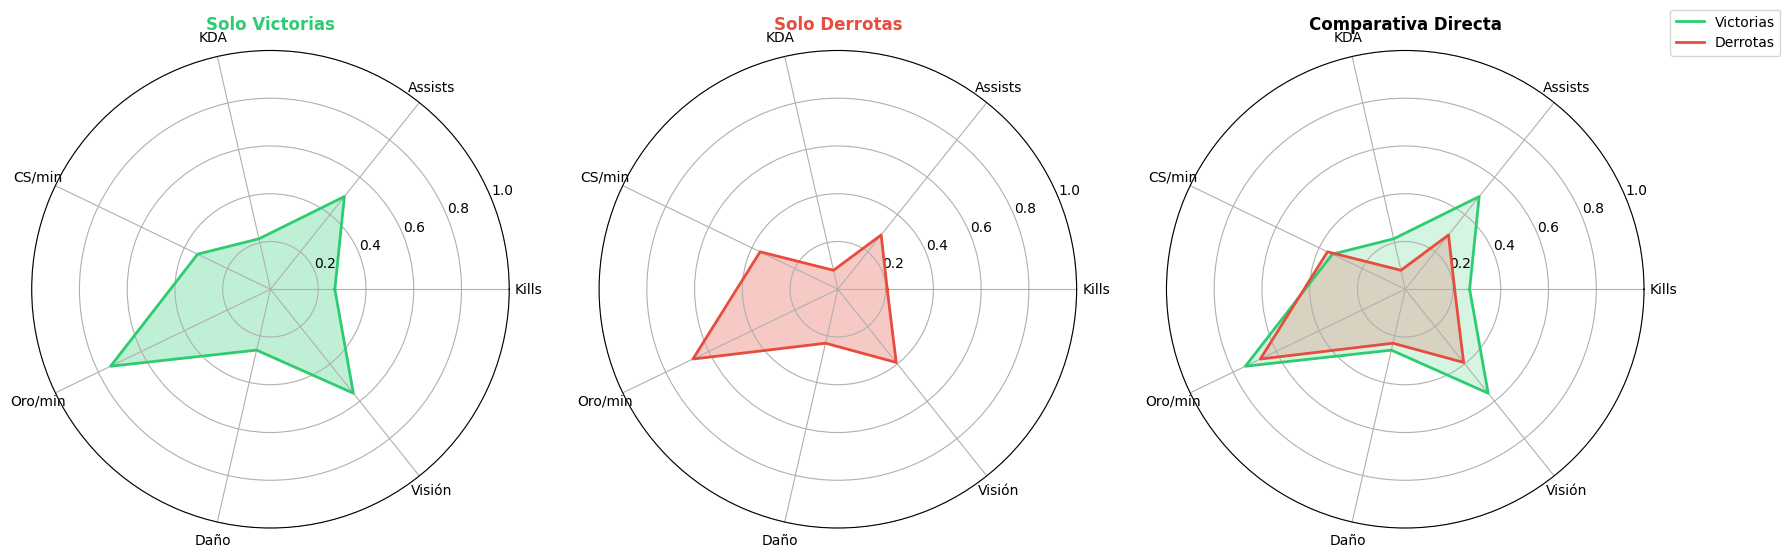

In [ ]:
# Promedio de cada estadística dividido entre su máximo histórico (escala de 0 a 1).

cols = ["kills", "assists", "kda", "cs_por_min", "gold_por_min", "damage_dealt", "vision_score"]
labels = ["Kills", "Assists", "KDA", "CS/min", "Oro/min", "Daño", "Visión"]

stats = df_matches.groupby("win")[cols].mean() / df_matches[cols].max()

angulos = np.linspace(0, 2 * np.pi, len(cols), endpoint=False).tolist()
angulos += angulos[:1]

vals_win = stats.loc[True].tolist() + [stats.loc[True].iloc[0]]
vals_loss = stats.loc[False].tolist() + [stats.loc[False].iloc[0]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5), subplot_kw=dict(polar=True))

# --- Gráfica 1: SOLO VICTORIAS ---
ax1.plot(angulos, vals_win, color="#2ecc71", linewidth=2)
ax1.fill(angulos, vals_win, color="#2ecc71", alpha=0.3)
ax1.set_xticks(angulos[:-1])
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1)
ax1.set_title("Solo Victorias", pad=15, color="#2ecc71", fontweight="bold")

# --- Gráfica 2: SOLO DERROTAS ---
ax2.plot(angulos, vals_loss, color="#e74c3c", linewidth=2)
ax2.fill(angulos, vals_loss, color="#e74c3c", alpha=0.3)
ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1)
ax2.set_title("Solo Derrotas", pad=15, color="#e74c3c", fontweight="bold")

# --- Gráfica 3: JUNTAS (COMPARACIÓN DIRECTA) ---
ax3.plot(angulos, vals_win, color="#2ecc71", linewidth=2, label="Victorias")
ax3.fill(angulos, vals_win, color="#2ecc71", alpha=0.2)
ax3.plot(angulos, vals_loss, color="#e74c3c", linewidth=2, label="Derrotas")
ax3.fill(angulos, vals_loss, color="#e74c3c", alpha=0.2)
ax3.set_xticks(angulos[:-1])
ax3.set_xticklabels(labels)
ax3.set_ylim(0, 1)
ax3.set_title("Comparativa Directa", pad=15, fontweight="bold")
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

###8. Consistencia

In [ ]:
metricas = [
    "kills", "deaths", "assists", "kda", "cs_por_min", "gold_por_min",
    "damage_dealt", "damage_taken", "vision_score", "wards_placed",
    "wards_killed", "duracion_minutos"
]

corr_win = (
    df_matches[metricas]
    .corrwith(df_matches["win"])
    .sort_values(ascending=False)
    .to_frame(name="correlacion_win")
    .round(3)
)

corr_win

,correlacion_win
kda,0.433
assists,0.429
wards_placed,0.352
vision_score,0.347
gold_por_min,0.287
duracion_minutos,0.243
wards_killed,0.232
kills,0.159
damage_taken,0.094
damage_dealt,0.092


###9. Pool de Campeones

###9.1 Campeones jugados

In [ ]:
print("## CAMPEONES JUGADOS")

pool_campeones = (
    df_matches["champion"]
    .value_counts()
    .rename_axis("champion")
    .reset_index(name="partidas")
)

pool_campeones["porcentaje_partidas"] = (
    pool_campeones["partidas"] /
    len(df_matches) * 100
)

display(pool_campeones.round(2))

## CAMPEONES JUGADOS


,champion,partidas,porcentaje_partidas
0,Pantheon,23,33.33
1,TahmKench,11,15.94
2,Leblanc,5,7.25
3,Galio,5,7.25
4,Rakan,4,5.80
5,Camille,4,5.80
6,Thresh,4,5.80
7,Nautilus,2,2.90
8,Senna,2,2.90
9,Rell,2,2.90


###9.2 Winrate por campeon

In [ ]:
#Winrate y estadisticas por campeon
metricas = ["kills", "deaths", "assists", "kda", "cs_por_min", "damage_dealt"]

campeones_stats = df_matches.groupby("champion").agg(
    partidas=("win", "count"),
    victorias=("win", "sum"),
    winrate=("win", lambda x: x.mean() * 100),
    **{m: (m, "mean") for m in metricas}
)

campeones_stats.insert(2, "derrotas", campeones_stats["partidas"] - campeones_stats["victorias"])
campeones_stats = campeones_stats.sort_values("partidas", ascending=False).round(2)

campeones_stats

,partidas,victorias,derrotas,winrate,kills,deaths,assists,kda,cs_por_min,damage_dealt
champion,,,,,,,,,,
Pantheon,23,10,13,43.48,5.78,7.35,9.48,3.05,2.00,18858.00
TahmKench,11,6,5,54.55,4.45,3.36,6.00,3.70,3.47,16945.36
Leblanc,5,3,2,60.00,3.60,5.20,14.20,4.18,1.66,13268.00
Galio,5,3,2,60.00,1.40,5.00,11.40,2.45,1.16,7757.40
Camille,4,0,4,0.00,2.75,8.50,8.25,1.11,1.25,14053.25
Thresh,4,3,1,75.00,1.50,6.25,8.50,3.91,1.39,8153.50
Rakan,4,3,1,75.00,1.25,3.50,11.00,5.95,1.20,6377.50
Nautilus,2,2,0,100.00,3.50,4.50,18.00,4.80,0.84,7501.00
Senna,2,1,1,50.00,6.00,8.50,16.00,2.59,1.21,24713.00


In [ ]:
campeones_muestra = campeones_stats[
    campeones_stats["partidas"] >= 5
].copy()

campeones_muestra = campeones_muestra.sort_values(
    "partidas",
    ascending=False
)

display(campeones_muestra.round(2))

,partidas,victorias,derrotas,winrate,kills,deaths,assists,kda,cs_por_min,damage_dealt
champion,,,,,,,,,,
Pantheon,23,10,13,43.48,5.78,7.35,9.48,3.05,2.00,18858.00
TahmKench,11,6,5,54.55,4.45,3.36,6.00,3.70,3.47,16945.36
Leblanc,5,3,2,60.00,3.60,5.20,14.20,4.18,1.66,13268.00
Galio,5,3,2,60.00,1.40,5.00,11.40,2.45,1.16,7757.40


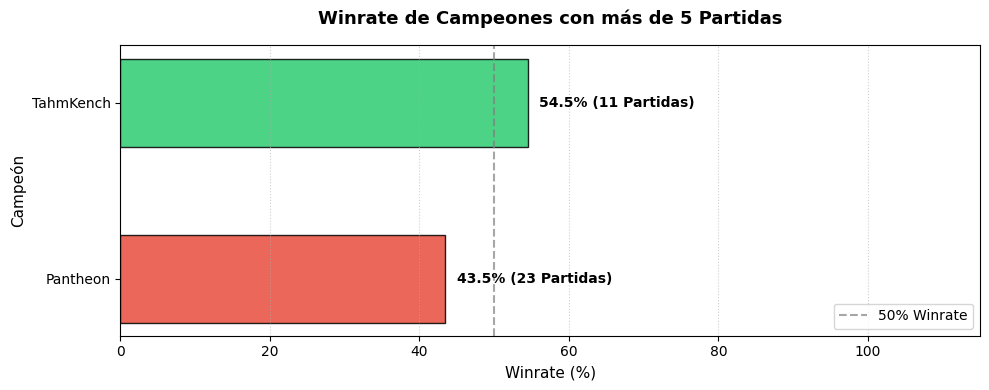

In [ ]:
# Filtrar campeones con estrictamente más de 5 partidas jugadas
df_filtrado = campeones_stats[campeones_stats["partidas"] > 5].sort_values("winrate", ascending=True)

plt.figure(figsize=(10, 4))

# Generar colores dinámicos según el rendimiento (verde para >= 50%, rojo para < 50%)
colores = ['#2ecc71' if wr >= 50 else '#e74c3c' for wr in df_filtrado['winrate']]

bars = plt.barh(
    df_filtrado.index,
    df_filtrado['winrate'],
    color=colores,
    edgecolor='black',
    alpha=0.85,
    height=0.5
)

# Añadir línea vertical de referencia al 50%
plt.axvline(50, color='gray', linestyle='--', alpha=0.7, label='50% Winrate')

# Agregar etiquetas de porcentaje y número de partidas
for bar, (idx, row) in zip(bars, df_filtrado.iterrows()):
    width = bar.get_width()
    plt.text(
        width + 1.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}% ({int(row['partidas'])} Partidas)",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

# Configuración de diseño
plt.title("Winrate de Campeones con más de 5 Partidas", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Winrate (%)", fontsize=11)
plt.ylabel("Campeón", fontsize=11)
plt.xlim(0, 115)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

###10. Posiciones

###10.1 Distribución de posiciones

position
UTILITY    58
TOP        11
Name: count, dtype: int64


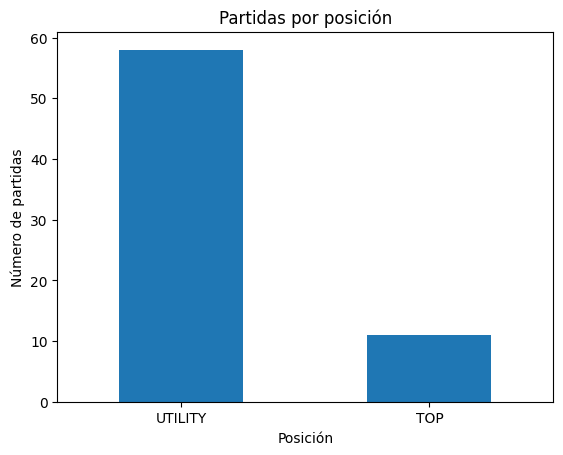

In [ ]:
posiciones = df_matches_detail["position"].value_counts()

print(posiciones)

posiciones.plot(kind="bar")

plt.title("Partidas por posición")
plt.xlabel("Posición")
plt.ylabel("Número de partidas")
plt.xticks(rotation=0)
plt.show()

###11.2 Rendimiento según posición

In [ ]:
rendimiento_posicion = df_matches_detail.groupby("position").agg(
    partidas=("match_id", "count"),
    victorias=("win", "sum"),
    winrate=("win", "mean"),
    kda_promedio=("kda", "mean"),
    cs_min_promedio=("cs_por_min", "mean"),
    oro_min_promedio=("gold_por_min", "mean"),
    vision_promedio=("vision_score", "mean")
).reset_index()

rendimiento_posicion["winrate"] *= 100

rendimiento_posicion.sort_values(
    "partidas",
    ascending=False
)

,position,partidas,victorias,winrate,kda_promedio,cs_min_promedio,oro_min_promedio,vision_promedio
1,UTILITY,58,31,53.448276,3.327586,1.539138,321.229310,59.551724
0,TOP,11,5,45.454545,2.479091,4.450000,302.209091,18.818182


In [ ]:
total_minutos = df_matches['duracion_minutos'].sum()
horas_totales = total_minutos / 60

print(f"El jugador ha acumulado un total de {horas_totales:.2f} horas de juego.")

El jugador ha acumulado un total de 35.88 horas de juego.
